In [152]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from inference.persona_registry import PersonaRegistry

plt.rcParams["font.family"] = "Roboto"

# Helpers

In [191]:
model_names = {
    "gemma-3-1b-it": "Gemma 3 1B",
    "gemma-3-4b-it": "Gemma 3 4B",
    "gpt-4-1-nano": "GPT 4.1 Nano",
    "gpt-5-nano": "GPT 5 Nano",
    "llama-3-2-1b-instruct": "Llama 3.2 1B",
    "llama-3-2-3b-instruct": "Llama 3.2 3B",
    "qwen3-0-6b": "Qwen3 0.6B",
    "qwen3-4b": "Qwen3 4B"
}

dataset_names = {
    "mmlu-pro": "MMLU-Pro",
    "alpaca": "Alpaca",
    "MATH": "MATH",
    "ifbench": "IFBench",
    "flores": "Flores"
}

In [192]:
dfs = []
for file in Path("data/evaluation/").iterdir():
    dataset_name = file.stem
    if file.suffix != ".csv":
        continue
    raw_df = pd.read_csv(file, index_col=0)
    raw_df = raw_df.rename(columns={"iso_639_3": "category", "subject": "category"})

    raw_df.insert(0, "dataset", dataset_name)
    if "flores" in dataset_name or "alpaca" in dataset_name:
        raw_df = raw_df[raw_df["score"] != 1]
        raw_df.loc[raw_df["score"] == 2, "score"] -= 1
    dfs.append(raw_df)
df = pd.concat(dfs, ignore_index=True)
df["model"] = df["model"].replace(model_names)
df["dataset"] = df["dataset"].replace(dataset_names)

In [158]:
persona_registry = PersonaRegistry()
persona_names = persona_registry.get_names()
persona_names = [p.replace("_persona", "") for p in persona_names]

plot_path = Path("plots/discussion")

# Word Cloud

In [ ]:
model_dir = Path("data/inference")
for persona in ["beginner_teacher_persona", "intermediate_teacher_persona", "expert_teacher_persona"]:

    persona_strings = ""
    for model_path in model_dir.iterdir():
        for dataset_file in model_path.iterdir():
            if dataset_file.suffix != ".parquet":
                continue
            df = pd.read_parquet(dataset_file)
            persona_col = df[persona]
            persona_col = persona_col.dropna()
            persona_strings += " ".join(persona_col.to_list())

    wordcloud = WordCloud(background_color="white", width=1200, height=600).generate(persona_strings)
    file_name = persona.split("_")[0]
    wordcloud.to_file(f"plots/discussion/03_wc_{file_name}.png")

# Model Sensitivity

In [9]:
test_path = Path("data/evaluation/tests")

test_dfs = {}
for test_file in test_path.iterdir():
    print(test_file)
    print(test_file.stem)
    if not test_file.suffix == ".csv":
        continue
    file_name = "_".join(test_file.stem.split("_")[1:])
    test_dfs[file_name] = pd.read_csv(test_file)

data/evaluation/tests/results_length_model.csv
results_length_model
data/evaluation/tests/results_static_vs_dynamic_model_lr.csv
results_static_vs_dynamic_model_lr
data/evaluation/tests/results_static_vs_dynamic_model.csv
results_static_vs_dynamic_model
data/evaluation/tests/results_teacher_model_lr.csv
results_teacher_model_lr
data/evaluation/tests/results_baseline_model.csv
results_baseline_model
data/evaluation/tests/results_length.csv
results_length
data/evaluation/tests/results_static_vs_dynamic.csv
results_static_vs_dynamic
data/evaluation/tests/results_teacher_model.csv
results_teacher_model
data/evaluation/tests/results_teacher.csv
results_teacher
data/evaluation/tests/results_baseline.csv
results_baseline
data/evaluation/tests/results_length_model_lr.csv
results_length_model_lr


## Significant personas

In [87]:
bs_model_df = test_dfs["baseline_model"].copy()
bs_model_df = bs_model_df[bs_model_df["term"].isin(persona_names)]
bs_model_df["Neutral"] = bs_model_df["pvalue"] >= 0.05
bs_model_df["Positive"] = (bs_model_df["pvalue"] < 0.05) & (bs_model_df["coef"] > 0)
bs_model_df["Negative"] = (bs_model_df["pvalue"] < 0.05) & (bs_model_df["coef"] < 0)
bs_model_df = bs_model_df.groupby("model", as_index=False).sum(numeric_only=True)
bs_model_df = bs_model_df[["model", "Positive", "Neutral", "Negative"]]
bs_model_df = bs_model_df.sort_values(by="Neutral", ascending=False)
bs_model_df["model"] = bs_model_df["model"].replace(model_names)

bs_model_df = bs_model_df.set_index("model")
bs_model_df = bs_model_df.div(bs_model_df.sum(axis=1), axis=0) * 100

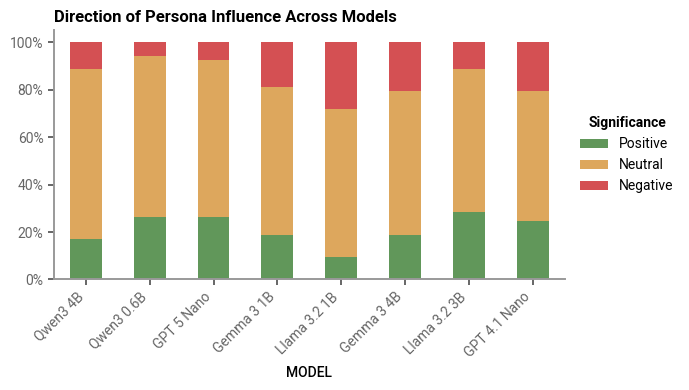

In [184]:
colors = {
    "Positive": "#61975A",
    "Neutral": "#DDA75D",
    "Negative": "#D45053",
}

fig, ax = plt.subplots(figsize=(7, 4))

ax = bs_model_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[colors[col] for col in bs_model_df.columns]
)

ax.set_xlabel("MODEL", fontweight="medium")
ax.set_title("Direction of Persona Influence Across Models", loc="left", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

legend = ax.legend(
    title="Significance",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    borderaxespad=0,
    frameon=False
)

legend.get_title().set_fontweight("bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.4)
    ax.spines[spine].set_color("0.6")

ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")

ax.tick_params(
    axis="both",
    which="both",
    colors="0.4",      # tick labels
    width=1.4,         # tick mark thickness
    length=4           # tick mark length
)

fig.tight_layout()
fig.savefig(plot_path / "02_significance", dpi=300)
plt.show()

## Per Model Persona Gain

In [193]:
whole_df = df.copy()
whole_df = whole_df.groupby(["model", "persona", "dataset"], as_index=False).mean(numeric_only=True)

parts = []
for (model_name, dataset_name), group_df in whole_df.groupby(["model", "dataset"], sort=False):
    if "helpful" in group_df["persona"].unique():
        ref = group_df.loc[group_df["persona"] == "helpful", "score"]
        ref_score = ref.iloc[0]
    else:
        ref_score = 1 - group_df["score"].mean()
    group_df["reference_score"] = ref_score
    group_df["Score Improvement"] = group_df["score"] - ref_score
    parts.append(group_df)

whole_df = pd.concat(parts)
whole_df = whole_df.sort_values("model")
whole_df = whole_df[whole_df["persona"] != "helpful"]

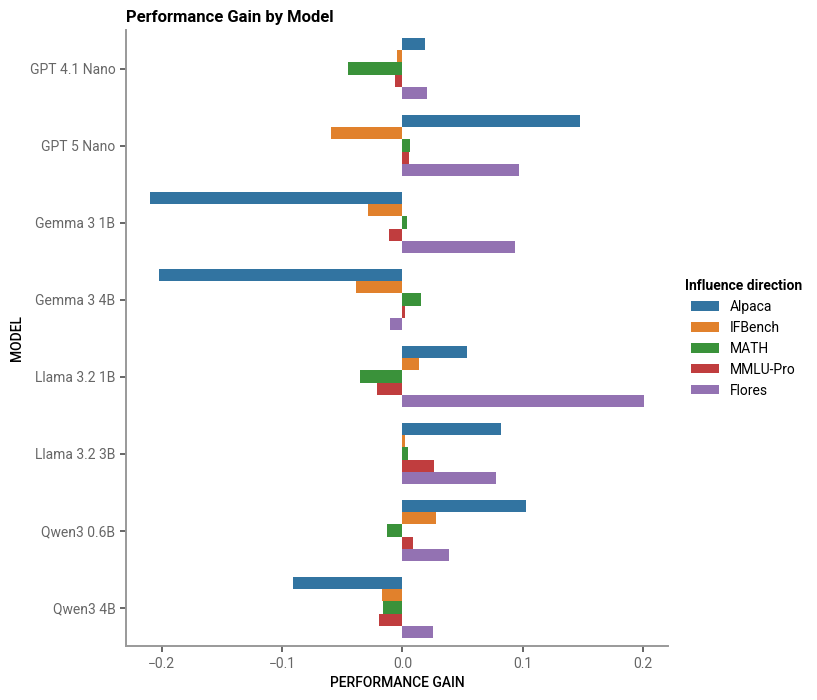

In [194]:
fig, ax = plt.subplots(figsize=(7, 8))

sns.barplot(whole_df, y="model", x="Score Improvement", orient="h", hue="dataset", errorbar=None, ax=ax)

ax.set_ylabel("MODEL", fontweight="medium")
ax.set_xlabel("PERFORMANCE GAIN", fontweight="medium")
ax.set_title("Performance Gain by Model", loc="left", fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Style remaining borders
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.4)
    ax.spines[spine].set_color("0.6")

ax.tick_params(
    axis="both",
    which="both",
    colors="0.4",
    width=1.4,
    length=4
)

legend = ax.legend(
    title="Influence direction",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    borderaxespad=0,
    frameon=False
)

legend.get_title().set_fontweight("bold")

# plt.savefig("plots/discussion/gain_per_model.png")